# Laboratorio 8: Random Forest y despliegues

**Duración:** 2 horas  
**Formato:** Implementación, despliegue y competencia  

---

## Portada del equipo

**Integrantes:**
- Nombre 1 (Usuario GitHub)
- Nombre 2 (Usuario GitHub)
- Nombre 3 (Usuario GitHub)

**Repositorio del equipo:**  
<https://github.com/usuario/equipoX>

**Fecha de entrega:**  
__/__/____

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,pairwise_distances, classification_report, confusion_matrix,precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
import time

In [40]:
df = pd.read_csv(r"D:./iris_train.csv")

cols_numericas = df.select_dtypes(include=np.number).columns.tolist()
col_clase = "target"   
print("Columnas numéricas:", cols_numericas)

Columnas numéricas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']


In [41]:
def detectar_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (df[col] < lower) | (df[col] > upper)

Outliers

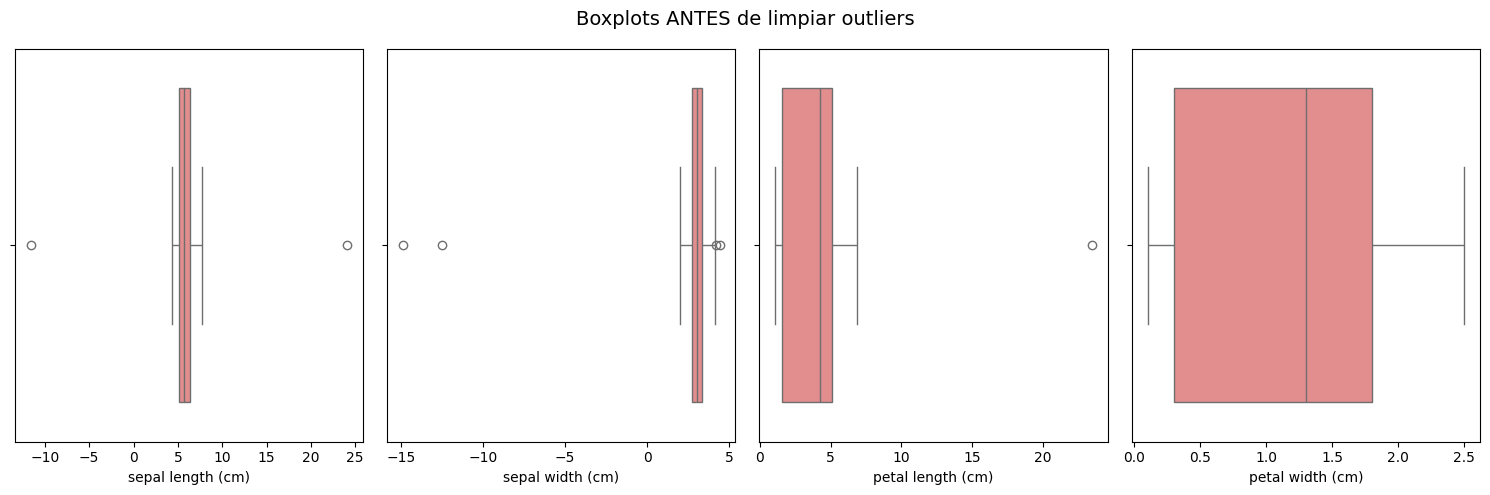

In [42]:
fig, axs = plt.subplots(1, len(cols_numericas)-1, figsize=(15,5))
fig.suptitle("Boxplots ANTES de limpiar outliers", fontsize=14)
for i, col in enumerate([c for c in cols_numericas if c != col_clase]):
    sns.boxplot(data=df, x=col, ax=axs[i], color='lightcoral')
plt.tight_layout()
plt.show()

In [43]:
def imputar_por_vecinos(df, indices_objetivo, indices_referencia, col, cols_numericas):
    # Matriz de referencia sin la columna objetivo
    X_ref = df.loc[indices_referencia, cols_numericas].drop(columns=[col])
    X_ref = X_ref.fillna(X_ref.mean())
    X_ref = X_ref.to_numpy()

    for idx in indices_objetivo:
        x_target = df.loc[idx, cols_numericas].drop(labels=[col])
        x_target = x_target.fillna(df[cols_numericas].mean())  
        x_target = x_target.to_numpy().reshape(1, -1)

        # Distancias euclidianas
        dists = pairwise_distances(x_target, X_ref)[0]
        vecinos_idx = np.argsort(dists)[:3]
        vecinos_real_idx = indices_referencia[vecinos_idx]
        promedio_vecinos = df.loc[vecinos_real_idx, col].mean()

        df.loc[idx, col] = round(promedio_vecinos, 1)

In [44]:
for col in cols_numericas:
    mask_outliers = detectar_outliers_iqr(df, col)
    if not mask_outliers.any():
        continue

    for clase in df[col_clase].unique():
        df_clase = df[df[col_clase] == clase]
        idx_out = df_clase[detectar_outliers_iqr(df_clase, col)].index
        idx_no_out = df_clase[~detectar_outliers_iqr(df_clase, col)].index

        if len(idx_no_out) < 3 or len(idx_out) == 0:
            continue

        imputar_por_vecinos(df, idx_out, idx_no_out, col, cols_numericas)

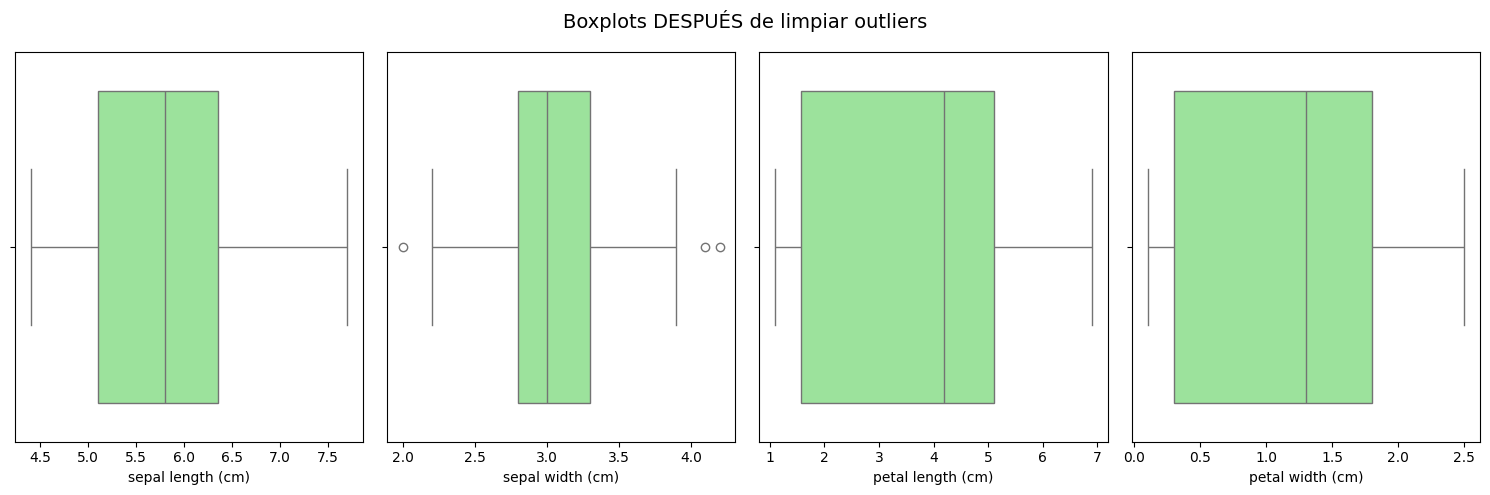

In [45]:
fig, axs = plt.subplots(1, len(cols_numericas)-1, figsize=(15,5))
fig.suptitle("Boxplots DESPUÉS de limpiar outliers", fontsize=14)
for i, col in enumerate([c for c in cols_numericas if c != col_clase]):
    sns.boxplot(data=df, x=col, ax=axs[i], color='lightgreen')
plt.tight_layout()
plt.show()

NA's

In [46]:
print("Valores NA antes de imputar:")
print(df.isna().sum())

Valores NA antes de imputar:
sepal length (cm)    2
sepal width (cm)     2
petal length (cm)    1
petal width (cm)     5
target               0
dtype: int64


In [47]:
for col in cols_numericas:
    na_mask = df[col].isna()
    if not na_mask.any():
        continue

    for clase in df[col_clase].unique():
        df_clase = df[df[col_clase] == clase]
        idx_na = df_clase[df_clase[col].isna()].index
        idx_no_na = df_clase[df_clase[col].notna()].index

        if len(idx_no_na) < 3 or len(idx_na) == 0:
            continue

        imputar_por_vecinos(df, idx_na, idx_no_na, col, cols_numericas)

In [48]:
print("Valores NA después de imputar:")
print(df.isna().sum())

Valores NA después de imputar:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [49]:
df.to_csv(r"D:./iris_train_totalmente_limpio.csv", index=False)

## Elemento 1 - Implementación del Random Forest

In [50]:
class SimpleRandomForest:
    def __init__(self, base_model='classifier', n_estimators=10, max_features='sqrt', random_state=None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.features_indices = []
        self.is_classifier = base_model == 'classifier'

        if self.is_classifier:
            self.model_class = DecisionTreeClassifier
        else:
            self.model_class = DecisionTreeRegressor

        np.random.seed(self.random_state)

    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    def _get_feature_subset(self, X):
        n_features = X.shape[1]
        if self.max_features == 'sqrt':
            n_sub_features = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            n_sub_features = int(np.log2(n_features))
        elif isinstance(self.max_features, int):
            n_sub_features = self.max_features
        else:
            n_sub_features = n_features

        feature_idx = np.random.choice(n_features, n_sub_features, replace=False)
        return feature_idx

    def fit(self, X, y):
        self.trees = []
        self.features_indices = []

        for i in range(self.n_estimators):
            X_sample, y_sample = self._bootstrap_sample(X, y)
            feat_idx = self._get_feature_subset(X_sample)

            tree = self.model_class(random_state=self.random_state)
            tree.fit(X_sample[:, feat_idx], y_sample)

            self.trees.append(tree)
            self.features_indices.append(feat_idx)

    def predict(self, X):
        all_preds = []

        for tree, feat_idx in zip(self.trees, self.features_indices):
            preds = tree.predict(X[:, feat_idx])
            all_preds.append(preds)

        all_preds = np.array(all_preds)

        if self.is_classifier:
            # Votación mayoritaria
            from scipy.stats import mode
            y_pred, _ = mode(all_preds, axis=0)
            return y_pred.flatten()
        else:
            # Promedio para regresión
            return np.mean(all_preds, axis=0)



In [51]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,4.4,2.9,1.4,0.2,0
1,6.1,2.5,4.5,1.7,2
2,6.8,2.8,4.8,1.4,1
3,4.9,3.1,1.5,0.1,0
4,5.5,2.5,4.0,1.3,1


In [57]:

X, y = df.drop('target', axis=1).values, df['target'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = SimpleRandomForest(base_model='classifier', n_estimators=5, max_features='sqrt', random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9736842105263158


In [53]:
# Guardar modelo entrenado en un archivo .pkl
import pickle

with open('modelo_entrenado.pkl', 'wb') as archivo:
    pickle.dump(rf, archivo)

### Elemento 1 - Preguntas teóricas

## Elemento 2 - Comparativa con scikit-learn

COMPARACIÓN: SimpleRandomForest vs Scikit-learn RandomForest


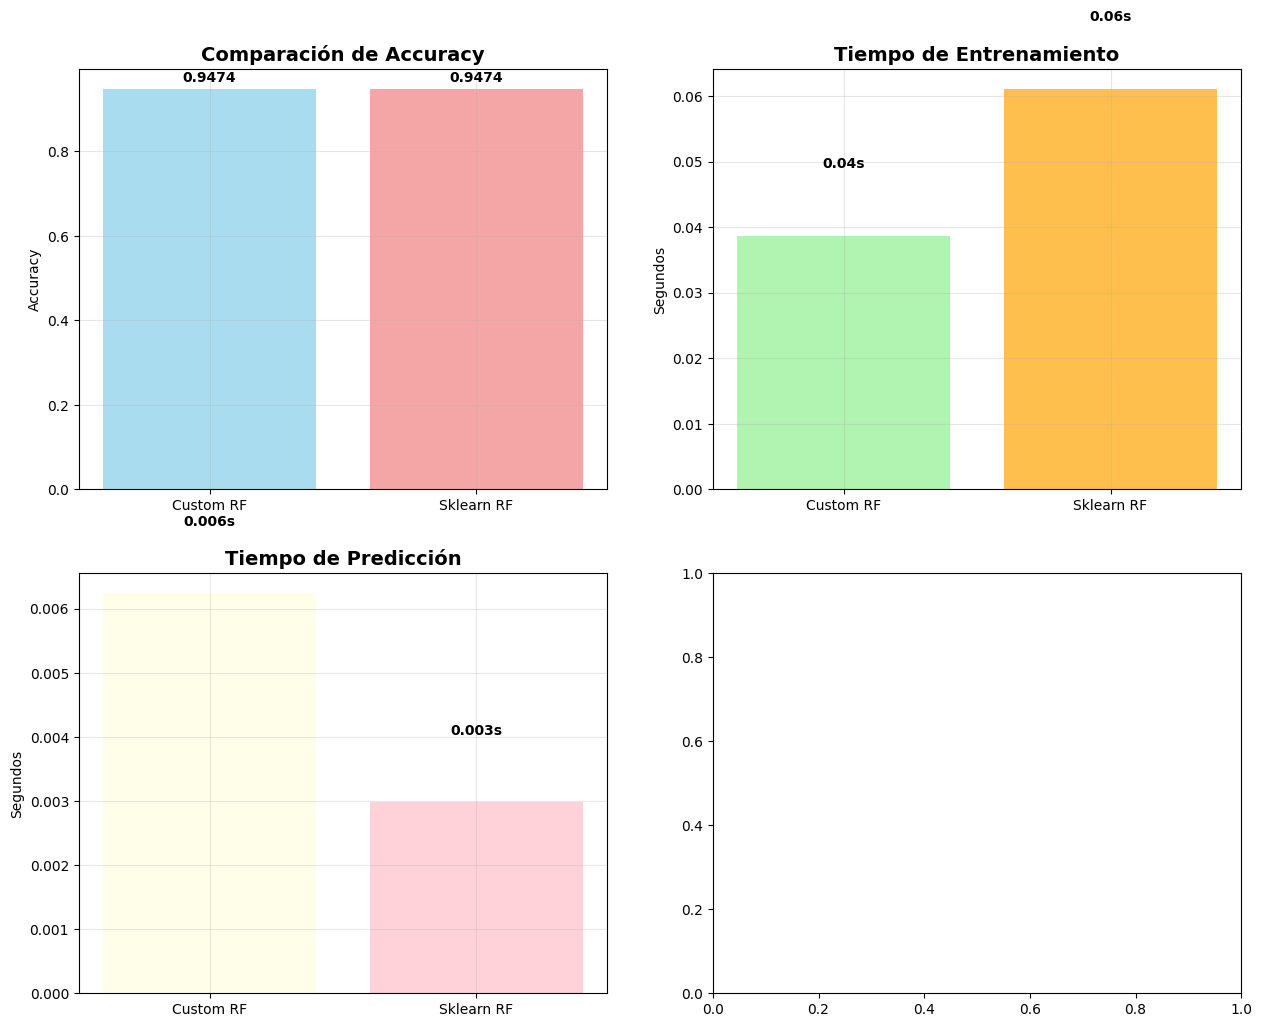

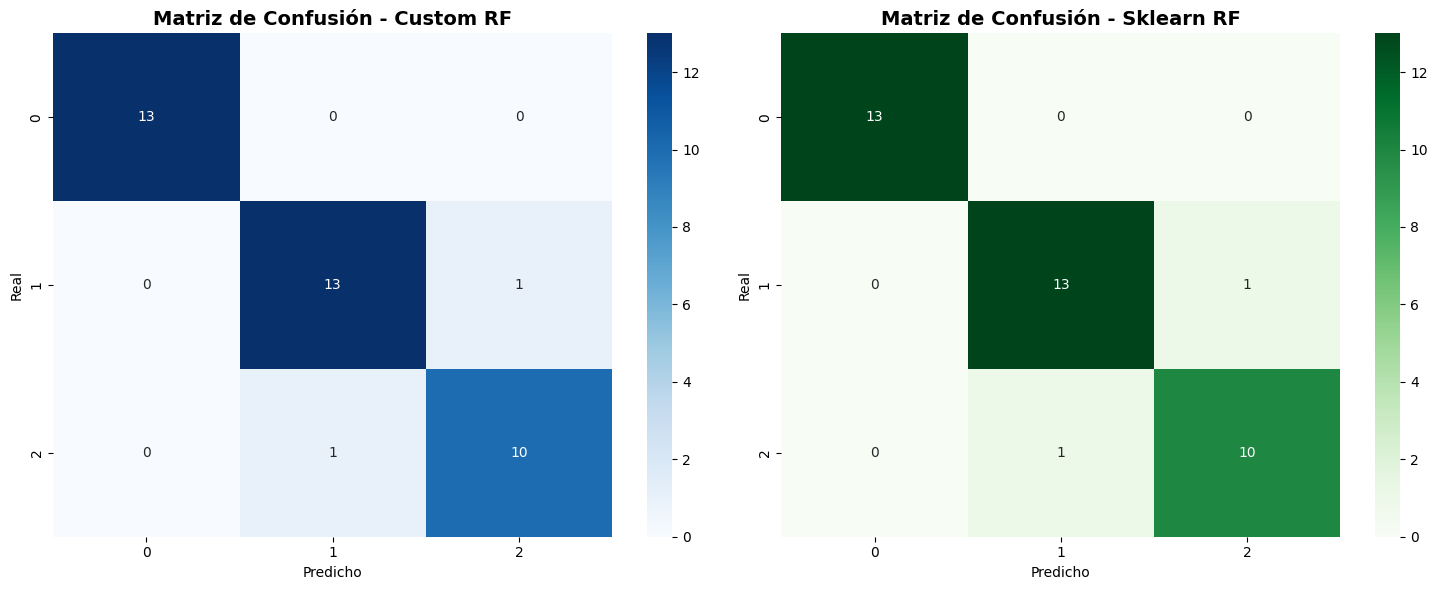


Comparando con diferentes números de estimadores...


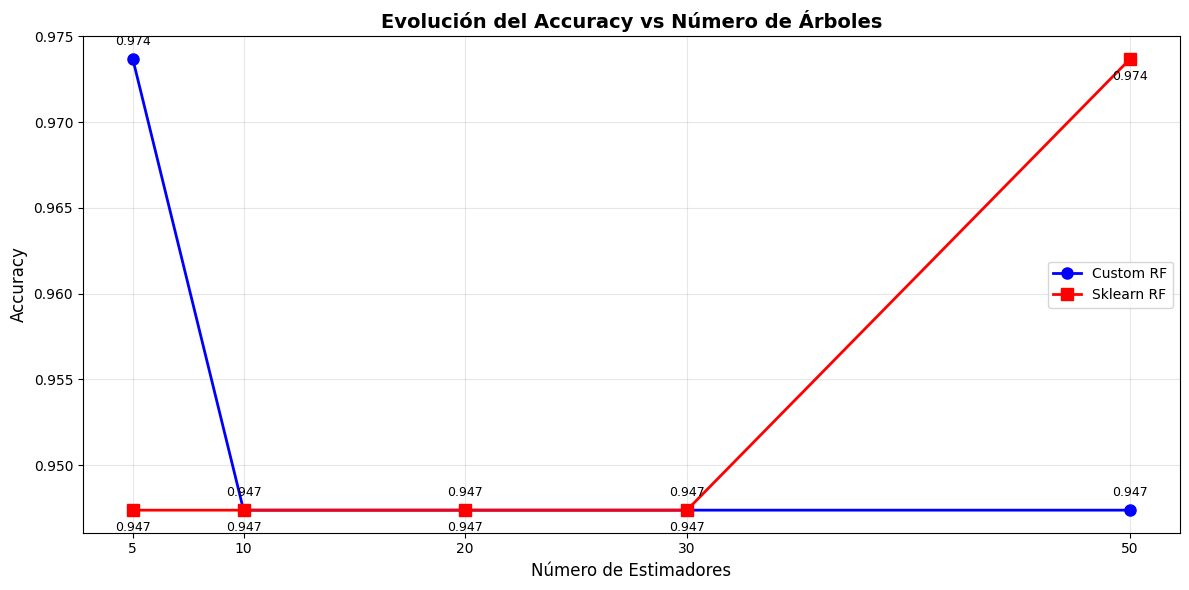


REPORTE DETALLADO DE COMPARACIÓN

📊 MÉTRICAS DE RENDIMIENTO:
Custom Random Forest - Accuracy: 0.9474
  Precision: 0.9474 | Recall: 0.9474 | F1-score: 0.9474
Sklearn Random Forest - Accuracy: 0.9474
  Precision: 0.9474 | Recall: 0.9474 | F1-score: 0.9474
Diferencia de Accuracy: 0.0000

⏰ TIEMPOS DE EJECUCIÓN:
Custom RF - Entrenamiento: 0.04s, Predicción: 0.006s
Sklearn RF - Entrenamiento: 0.06s, Predicción: 0.003s

⚡ VELOCIDAD RELATIVA:
Entrenamiento: 0.63x más rápido
Predicción: 2.09x más lento

📈 MEJORA CON MÁS ÁRBOLES:
Custom RF: De 5 a 50 árboles: +-0.0263
Sklearn RF: De 5 a 50 árboles: +0.0263


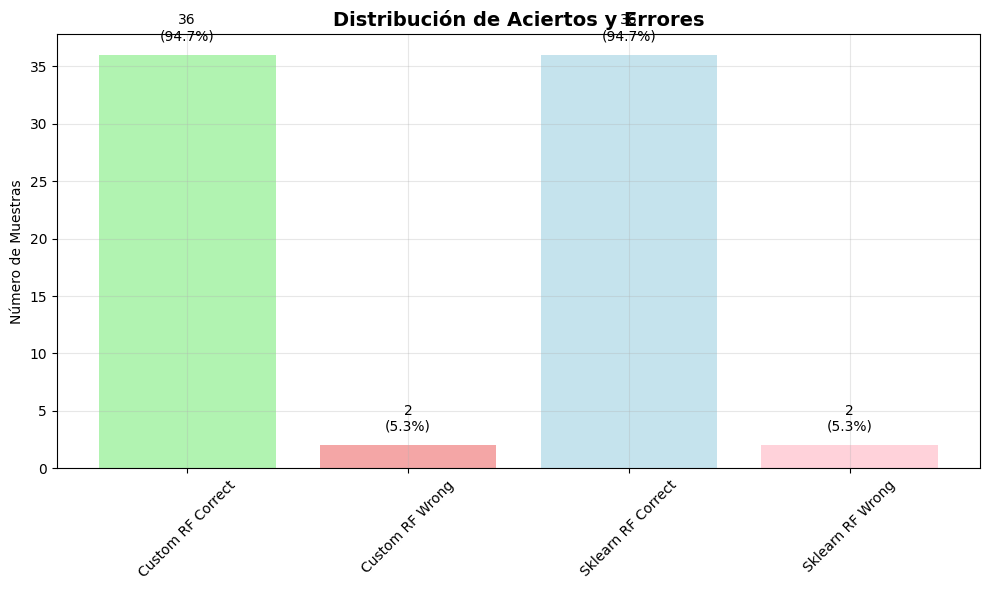


✅ RESUMEN FINAL:
¡Excelente trabajo! Tu implementación tiene un rendimiento comparable a scikit-learn.


In [54]:
#  COMPARACIÓN DE PRECISIÓN Y TIEMPOS
print("=" * 60)
print("COMPARACIÓN: SimpleRandomForest vs Scikit-learn RandomForest")
print("=" * 60)

# El modelo desde cero
start_time = time.time()
rf_custom = SimpleRandomForest(base_model='classifier', n_estimators=20, max_features='sqrt', random_state=42)
rf_custom.fit(X_train, y_train)
custom_fit_time = time.time() - start_time

start_time = time.time()
y_pred_custom = rf_custom.predict(X_test)
custom_predict_time = time.time() - start_time

custom_accuracy = accuracy_score(y_test, y_pred_custom)

# Modelo de scikit-learn
start_time = time.time()
rf_sklearn = RandomForestClassifier(n_estimators=20, max_features='sqrt', random_state=42)
rf_sklearn.fit(X_train, y_train)
sklearn_fit_time = time.time() - start_time

start_time = time.time()
y_pred_sklearn = rf_sklearn.predict(X_test)
sklearn_predict_time = time.time() - start_time

sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)

# 2. GRÁFICA DE COMPARACIÓN DE MÉTRICAS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfica 1: Comparación de Accuracy
metrics_comparison = pd.DataFrame({
    'Modelo': ['Custom RF', 'Sklearn RF'],
    'Accuracy': [custom_accuracy, sklearn_accuracy],
    'Tiempo Entrenamiento (s)': [custom_fit_time, sklearn_fit_time],
    'Tiempo Predicción (s)': [custom_predict_time, sklearn_predict_time]
})

axes[0, 0].bar(metrics_comparison['Modelo'], metrics_comparison['Accuracy'], 
               color=['skyblue', 'lightcoral'], alpha=0.7)
axes[0, 0].set_title('Comparación de Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(metrics_comparison['Accuracy']):
    axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# Gráfica 2: Comparación de Tiempos de Entrenamiento
axes[0, 1].bar(metrics_comparison['Modelo'], metrics_comparison['Tiempo Entrenamiento (s)'],
               color=['lightgreen', 'orange'], alpha=0.7)
axes[0, 1].set_title('Tiempo de Entrenamiento', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Segundos')
axes[0, 1].grid(True, alpha=0.3)

for i, v in enumerate(metrics_comparison['Tiempo Entrenamiento (s)']):
    axes[0, 1].text(i, v + 0.01, f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

# Gráfica 3: Comparación de Tiempos de Predicción
axes[1, 0].bar(metrics_comparison['Modelo'], metrics_comparison['Tiempo Predicción (s)'],
               color=['lightyellow', 'pink'], alpha=0.7)
axes[1, 0].set_title('Tiempo de Predicción', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Segundos')
axes[1, 0].grid(True, alpha=0.3)

for i, v in enumerate(metrics_comparison['Tiempo Predicción (s)']):
    axes[1, 0].text(i, v + 0.001, f'{v:.3f}s', ha='center', va='bottom', fontweight='bold')



# 3. MATRICES DE CONFUSIÓN COMPARATIVAS
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Matriz de confusión para Custom RF
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión - Custom RF', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz de confusión para Sklearn RF
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión - Sklearn RF', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

# 4. COMPARACIÓN CON DIFERENTES NÚMEROS DE ESTIMADORES
n_estimators_range = [5, 10, 20, 30, 50]
custom_accuracies = []
sklearn_accuracies = []

print("\nComparando con diferentes números de estimadores...")
for n_est in n_estimators_range:
    # Custom RF
    rf_custom_temp = SimpleRandomForest(base_model='classifier', n_estimators=n_est, 
                                       max_features='sqrt', random_state=42)
    rf_custom_temp.fit(X_train, y_train)
    y_pred_temp = rf_custom_temp.predict(X_test)
    custom_accuracies.append(accuracy_score(y_test, y_pred_temp))
    
    # Sklearn RF
    rf_sklearn_temp = RandomForestClassifier(n_estimators=n_est, max_features='sqrt', 
                                           random_state=42)
    rf_sklearn_temp.fit(X_train, y_train)
    y_pred_temp = rf_sklearn_temp.predict(X_test)
    sklearn_accuracies.append(accuracy_score(y_test, y_pred_temp))

# Gráfica de evolución con número de estimadores
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, custom_accuracies, 'o-', linewidth=2, markersize=8, 
         label='Custom RF', color='blue')
plt.plot(n_estimators_range, sklearn_accuracies, 's-', linewidth=2, markersize=8, 
         label='Sklearn RF', color='red')
plt.xlabel('Número de Estimadores', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Evolución del Accuracy vs Número de Árboles', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(n_estimators_range)

# Añadir anotaciones para los puntos
for i, (x, y1, y2) in enumerate(zip(n_estimators_range, custom_accuracies, sklearn_accuracies)):
    plt.annotate(f'{y1:.3f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
    plt.annotate(f'{y2:.3f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Cálculo de métricas adicionales
custom_precision = precision_score(y_test, y_pred_custom, average='weighted')
custom_recall = recall_score(y_test, y_pred_custom, average='weighted')
custom_f1 = f1_score(y_test, y_pred_custom, average='weighted')

sklearn_precision = precision_score(y_test, y_pred_sklearn, average='weighted')
sklearn_recall = recall_score(y_test, y_pred_sklearn, average='weighted')
sklearn_f1 = f1_score(y_test, y_pred_sklearn, average='weighted')

# 5. REPORTE COMPARATIVO DETALLADO
print("\n" + "=" * 60)
print("REPORTE DETALLADO DE COMPARACIÓN")
print("=" * 60)

print(f"\n📊 MÉTRICAS DE RENDIMIENTO:")
print(f"Custom Random Forest - Accuracy: {custom_accuracy:.4f}")
print(f"  Precision: {custom_precision:.4f} | Recall: {custom_recall:.4f} | F1-score: {custom_f1:.4f}")
print(f"Sklearn Random Forest - Accuracy: {sklearn_accuracy:.4f}")
print(f"  Precision: {sklearn_precision:.4f} | Recall: {sklearn_recall:.4f} | F1-score: {sklearn_f1:.4f}")
print(f"Diferencia de Accuracy: {sklearn_accuracy - custom_accuracy:.4f}")


print(f"\n⏰ TIEMPOS DE EJECUCIÓN:")
print(f"Custom RF - Entrenamiento: {custom_fit_time:.2f}s, Predicción: {custom_predict_time:.3f}s")
print(f"Sklearn RF - Entrenamiento: {sklearn_fit_time:.2f}s, Predicción: {sklearn_predict_time:.3f}s")

print(f"\n⚡ VELOCIDAD RELATIVA:")
print(f"Entrenamiento: {custom_fit_time/sklearn_fit_time:.2f}x más {'lento' if custom_fit_time > sklearn_fit_time else 'rápido'}")
print(f"Predicción: {custom_predict_time/sklearn_predict_time:.2f}x más {'lento' if custom_predict_time > sklearn_predict_time else 'rápido'}")

print(f"\n📈 MEJORA CON MÁS ÁRBOLES:")
final_improvement_custom = custom_accuracies[-1] - custom_accuracies[0]
final_improvement_sklearn = sklearn_accuracies[-1] - sklearn_accuracies[0]
print(f"Custom RF: De {n_estimators_range[0]} a {n_estimators_range[-1]} árboles: +{final_improvement_custom:.4f}")
print(f"Sklearn RF: De {n_estimators_range[0]} a {n_estimators_range[-1]} árboles: +{final_improvement_sklearn:.4f}")

# 6. GRÁFICA DE DISTRIBUCIÓN DE PREDICCIONES
plt.figure(figsize=(10, 6))

# Crear un DataFrame para comparar predicciones
comparison_df = pd.DataFrame({
    'y_test': y_test,
    'Custom_RF': y_pred_custom,
    'Sklearn_RF': y_pred_sklearn
})

# Contar aciertos y errores
custom_correct = (comparison_df['y_test'] == comparison_df['Custom_RF']).sum()
sklearn_correct = (comparison_df['y_test'] == comparison_df['Sklearn_RF']).sum()
total_samples = len(comparison_df)

plt.bar(['Custom RF Correct', 'Custom RF Wrong', 'Sklearn RF Correct', 'Sklearn RF Wrong'],
        [custom_correct, total_samples - custom_correct, sklearn_correct, total_samples - sklearn_correct],
        color=['lightgreen', 'lightcoral', 'lightblue', 'pink'], alpha=0.7)

plt.title('Distribución de Aciertos y Errores', fontsize=14, fontweight='bold')
plt.ylabel('Número de Muestras')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# Añadir porcentajes
for i, v in enumerate([custom_correct, total_samples - custom_correct, 
                      sklearn_correct, total_samples - sklearn_correct]):
    percentage = (v / total_samples) * 100
    plt.text(i, v + 1, f'{v}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n✅ RESUMEN FINAL:")
if custom_accuracy >= sklearn_accuracy * 0.95:  # Si está dentro del 95% del accuracy de sklearn
    print("¡Excelente trabajo! Tu implementación tiene un rendimiento comparable a scikit-learn.")
else:
    print("Tu implementación puede mejorarse. Revisa posibles áreas de optimización.")

In [55]:
help(RandomForestClassifier)

Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(
 |      n_estimators=100,
 |      *,
 |      criterion='gini',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features='sqrt',
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      bootstrap=True,
 |      oob_score=False,
 |      n_jobs=None,
 |      random_state=None,
 |      verbose=0,
 |      warm_start=False,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      max_samples=None,
 |      monotonic_cst=None
 |  )
 |
 |  A random forest classifier.
 |
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to p

### Elemento 2 - Preguntas teóricas

## Elemento 3 - Creación y despliegue de la API

### Elemento 3 - Preguntas teóricas